In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

In [23]:
coords = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/coords_human.csv',index_col=0)
coords.head()

,imagerow,imagecol
S3A_AAACAAGTATCTCCCA-1,427.058072,334.373952
S3A_AAACACCAATAACTGC-1,179.466660,382.026456
S3A_AAACAGAGCGACTCCT-1,402.480377,147.484499
S3A_AAACAGCTTTCAGAAG-1,149.317287,299.037788
S3A_AAACAGGGTCTATATT-1,161.322053,319.766627


In [33]:
data = ad.read_h5ad("/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/human_sobj_transformed_projected.h5ad")
clinical_meta = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/clinical_meta_merged_updateSampleID.csv', index_col=0)
clinical_meta['Subject_newID'] = clinical_meta['Subject_newID'].fillna('NA')
clinical_meta['patient'] = clinical_meta.loc[:,'Subject_newID']

data.obs['patient'] = clinical_meta.loc[data.obs.index,'Subject_newID']
data.obs['patient_replicate'] = data.obs['patient'] + "_" + data.obs['replicate']

/tmp/ipykernel_581287/3457134305.py:2: DtypeWarning: Columns (55,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_meta = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/clinical_meta_merged_updateSampleID.csv', index_col=0)


In [34]:
geneWeights = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/human_CB_cogaps_n30_nIterations15k_allGenes_geneWeights.csv', index_col=0)
geneWeights.shape

(29963, 28)

In [35]:
patterns = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/human_CB_cogaps_n30_nIterations15k_allGenes_patterns.csv',index_col=0).T
n_patterns = patterns.shape[1]
data.obsm['cogaps_patterns'] = patterns
patterns.head()

,Pattern_1,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,...,Pattern_19,Pattern_20,Pattern_21,Pattern_22,Pattern_23,Pattern_24,Pattern_25,Pattern_26,Pattern_27,Pattern_28
S3A_AAACAAGTATCTCCCA-1,0.000283,0.149200,0.034857,0.050816,0.049332,0.039981,0.000074,0.027770,0.266223,0.054593,...,0.324894,0.120899,0.064320,0.000068,0.000102,0.771052,0.000163,0.000001,0.677916,0.162847
S3A_AAACACCAATAACTGC-1,0.000212,0.092461,0.000304,0.030230,0.027633,0.311059,0.000002,0.040052,0.041184,0.088976,...,0.563830,0.090620,0.026578,0.266080,0.000048,0.261119,0.018544,0.069124,0.516153,0.054962
S3A_AAACAGAGCGACTCCT-1,0.000364,0.022568,0.088275,0.000054,0.008502,0.205238,0.030788,0.039830,0.000001,0.054160,...,0.444288,0.039318,0.013559,0.494464,0.000007,0.000014,0.000890,0.033845,0.369910,0.071675
S3A_AAACAGCTTTCAGAAG-1,0.053770,0.026755,0.000080,0.027685,0.001049,0.212877,0.085334,0.035711,0.013748,0.073234,...,0.468388,0.092631,0.031537,0.525399,0.024869,0.000867,0.020535,0.013502,0.192469,0.015162
S3A_AAACAGGGTCTATATT-1,0.078365,0.075513,0.000681,0.004797,0.000332,0.122380,0.017096,0.035357,0.006012,0.001737,...,0.315560,0.073416,0.027714,0.527423,0.030247,0.065046,0.000250,0.056316,0.493115,0.150277


In [36]:
#clinical_meta = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/clinical_meta_merged.csv', index_col=0)
clinical_meta['patient_replicate'] = clinical_meta.apply(lambda x: str(x['patient']) + "_" + x['replicate'],axis=1)


In [37]:
patterns_selected = patterns.loc[:,[ 'Pattern_16','Pattern_17','Pattern_27']]

In [ ]:
for col in patterns_selected.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(patterns_selected.loc[:,col], bins=100)
    plt.yscale('log')


In [ ]:
binary = pd.DataFrame(columns=[x + '_90' for x in patterns_selected.columns] + [x + '_95' for x in patterns_selected.columns], index=data.obs_names)

for pat in patterns_selected.columns:
    pattern_full = data.obsm['cogaps_patterns'].loc[:,pat] # per pattern
    cutoff = np.percentile(pattern_full, 90)
    pattern_binary = [1 if x > cutoff else 0 for x in pattern_full]
    binary[pat + '_90'] = pattern_binary

for pat in patterns_selected.columns:
    pattern_full = data.obsm['cogaps_patterns'].loc[:,pat] # per pattern
    cutoff = np.percentile(pattern_full, 95)
    pattern_binary = [1 if x > cutoff else 0 for x in pattern_full]
    binary[pat + '_95'] = pattern_binary

binary.head()

In [ ]:
samples = clinical_meta.sort_values(by=['Gestational Age (Weeks)','patient_replicate']).loc[:,'patient_replicate'].unique()

for pat in binary.columns:
    pattern_full = binary.loc[:,pat] # per pattern
    fig,axes = plt.subplots(6,4,figsize=(24,24),sharex=True,sharey=True)
    i = 0
    for c in range(axes.shape[1]):
        for r in range(axes.shape[0]):
            sample = samples[i]
            patterns_sub = binary.loc[data.obs['patient_replicate'] == sample,:]
            axes[r,c].set(aspect='equal')
            #scat_background = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=1, alpha=0.1,c='gray')
            scat = axes[r,c].scatter(coords.loc[patterns_sub.index,'imagerow'],coords.loc[patterns_sub.index,'imagecol'], s=6,c=patterns_sub.loc[:,pat],cmap='viridis', vmin=0, vmax=1)
            #axes[r,c].set_box_aspect(1)
            #print(sample.unique())

            axes[r,c].set_yticklabels([])
            axes[r,c].set_xticklabels([])
            axes[r,c].set_xticks([])
            axes[r,c].set_yticks([])

            axes[r,c].set_title(f"{sample}")
            fig.colorbar(scat, ax=axes[r,c])

            #plt.color_bar()
            #fig.colorbar(ax=ax)
            #plt.color_bar()
            i+=1
    plt.suptitle(f"{pat}th percentile", fontsize=16)
    plt.tight_layout()
    #plt.savefig(f"/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/tricycle_pattern_plots/binary_patterns/{pat}.pdf", bbox_inches='tight')

In [ ]:
binary.to_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/tricycle_pattern_plots/patterns_binary.csv')

#### PLOT SPATIAL

In [41]:
hex_colors = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/theta_hex_colors.csv',index_col=0)
hex_colors = hex_colors.set_index('angle')

from matplotlib.colors import LinearSegmentedColormap
RugPalette_v = ["#2E22EA", "#9E3DFB", "#F86BE2", "#FCCE7B", "#C4E416", "#4BBA0F", "#447D87", "#2C24E9"]
rug_cmap = LinearSegmentedColormap.from_list("RugPalette", RugPalette_v)


In [42]:
tricycle_pos = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/results/human_Spatial/tricyclePosition.csv',index_col=0)
tricycle_pos['tricyclePosition_theta'] = tricycle_pos['tricyclePosition']/np.pi


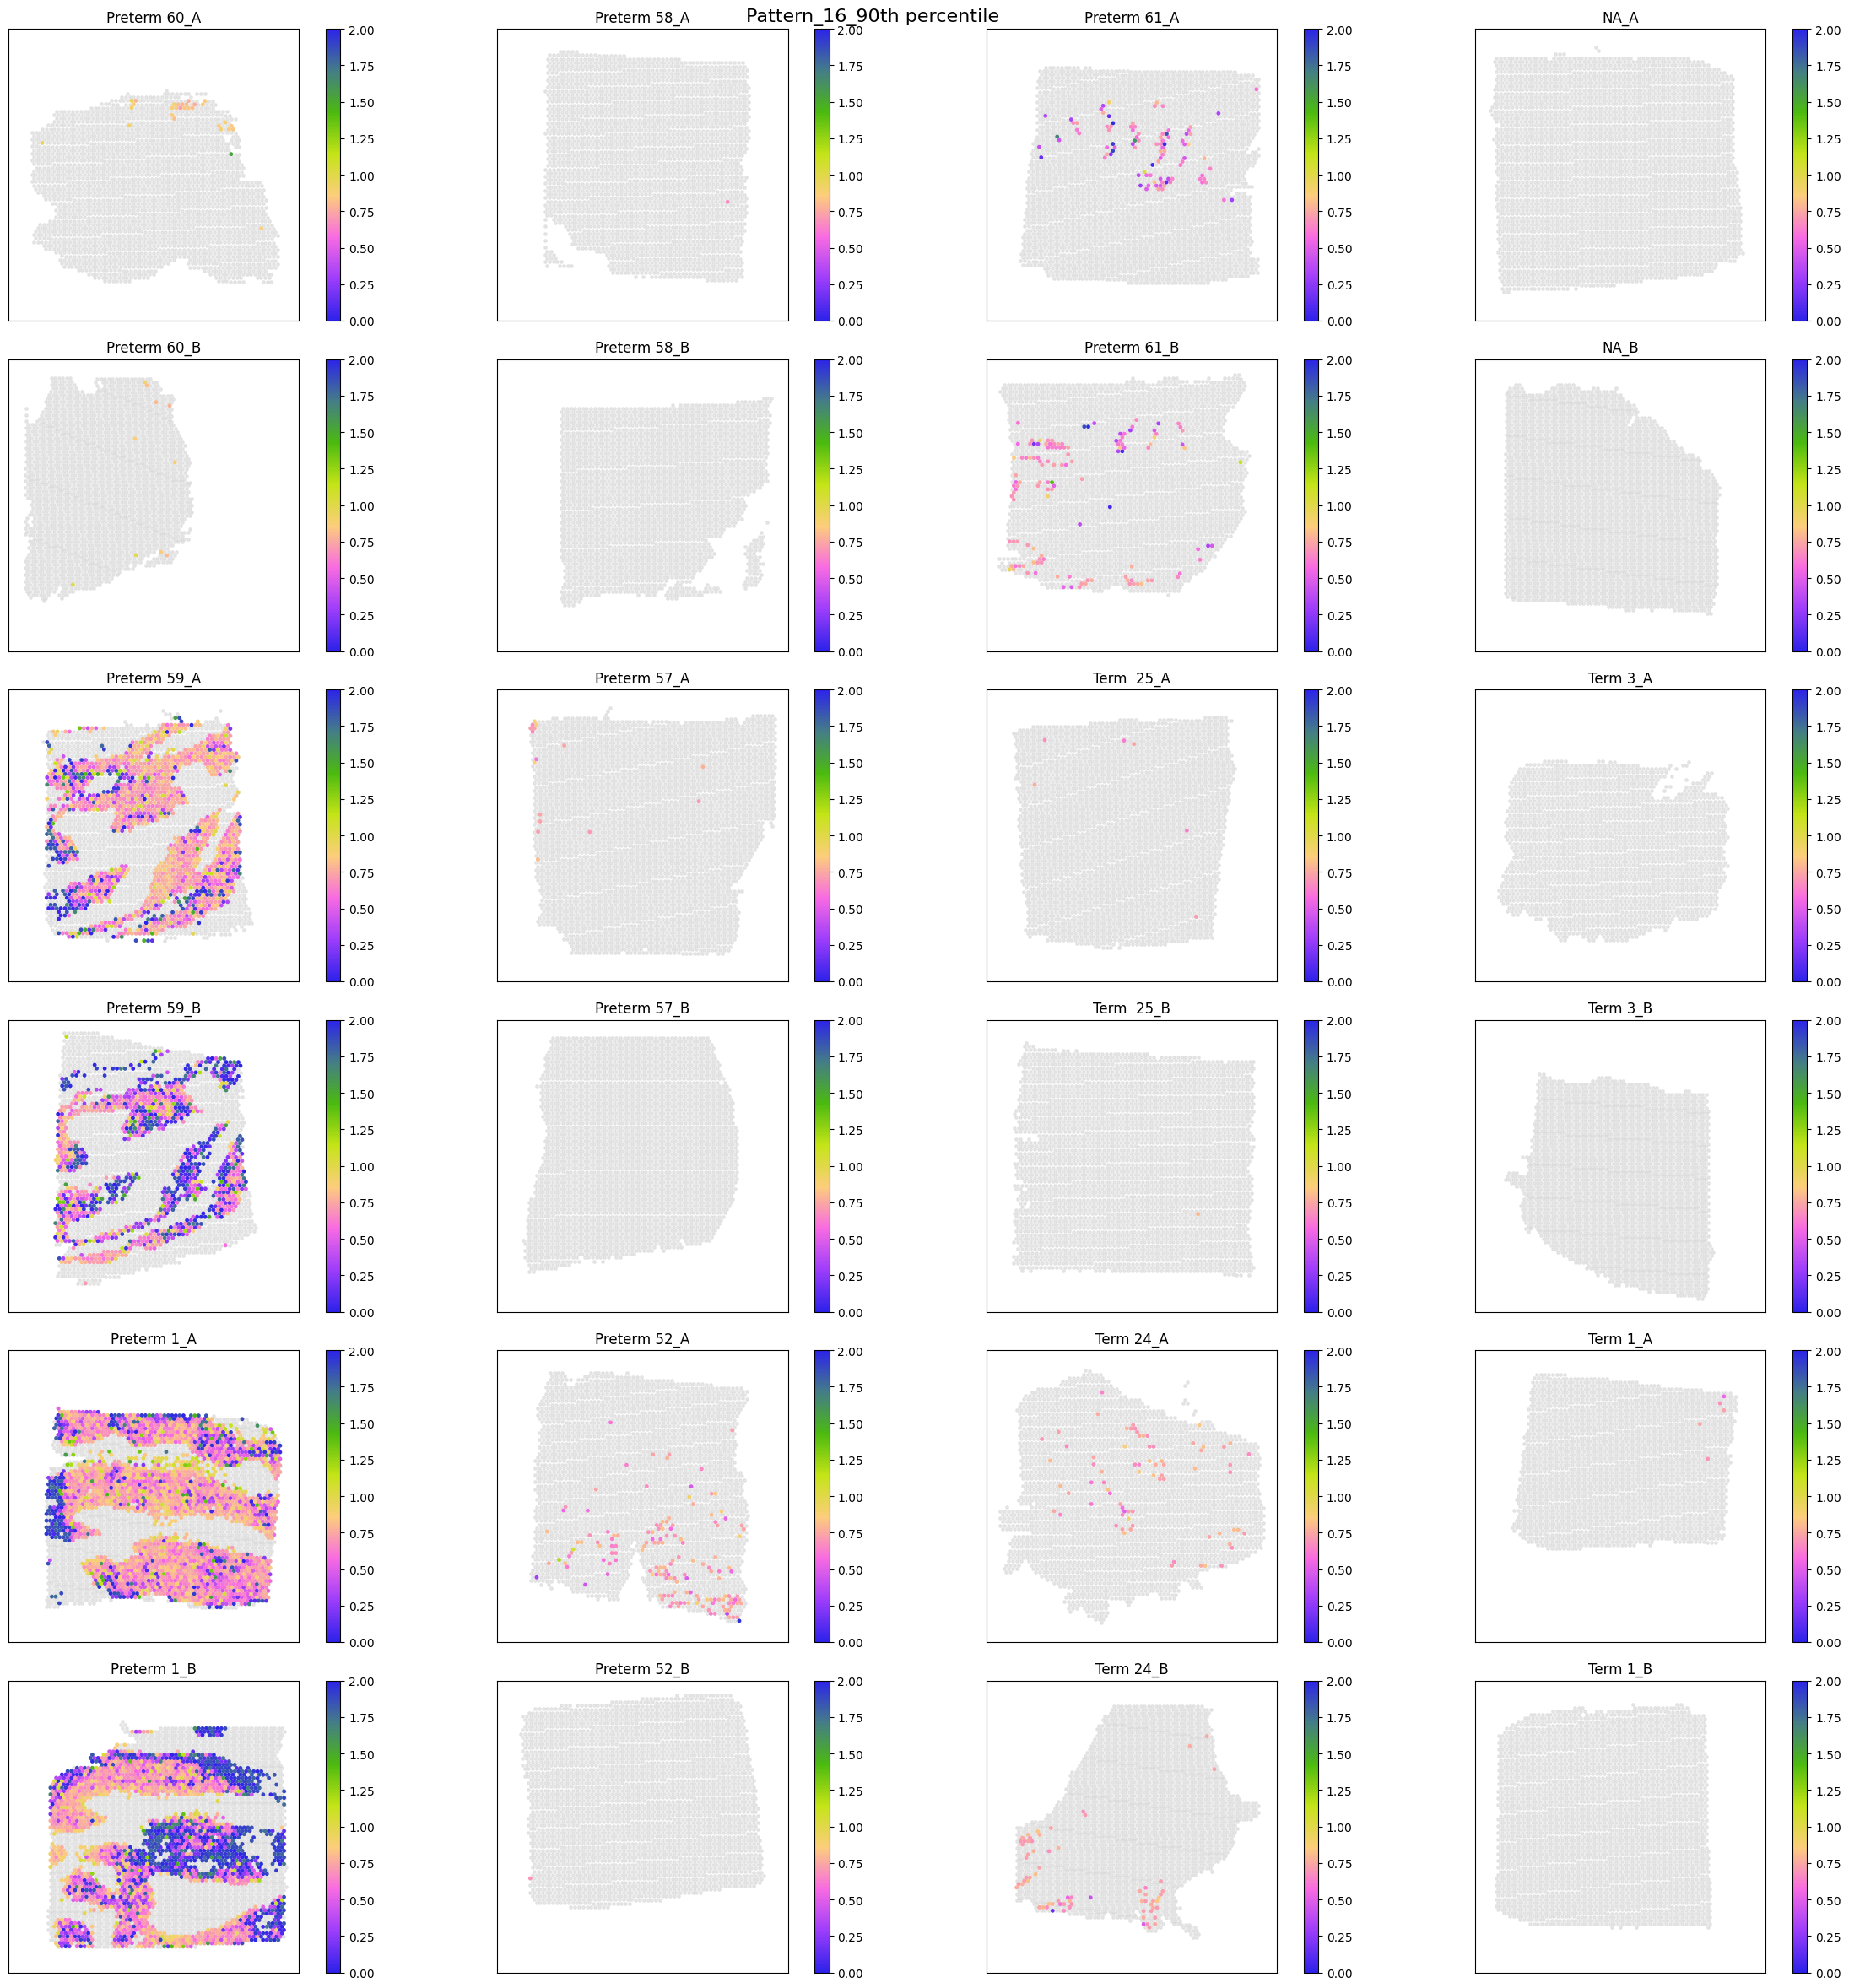

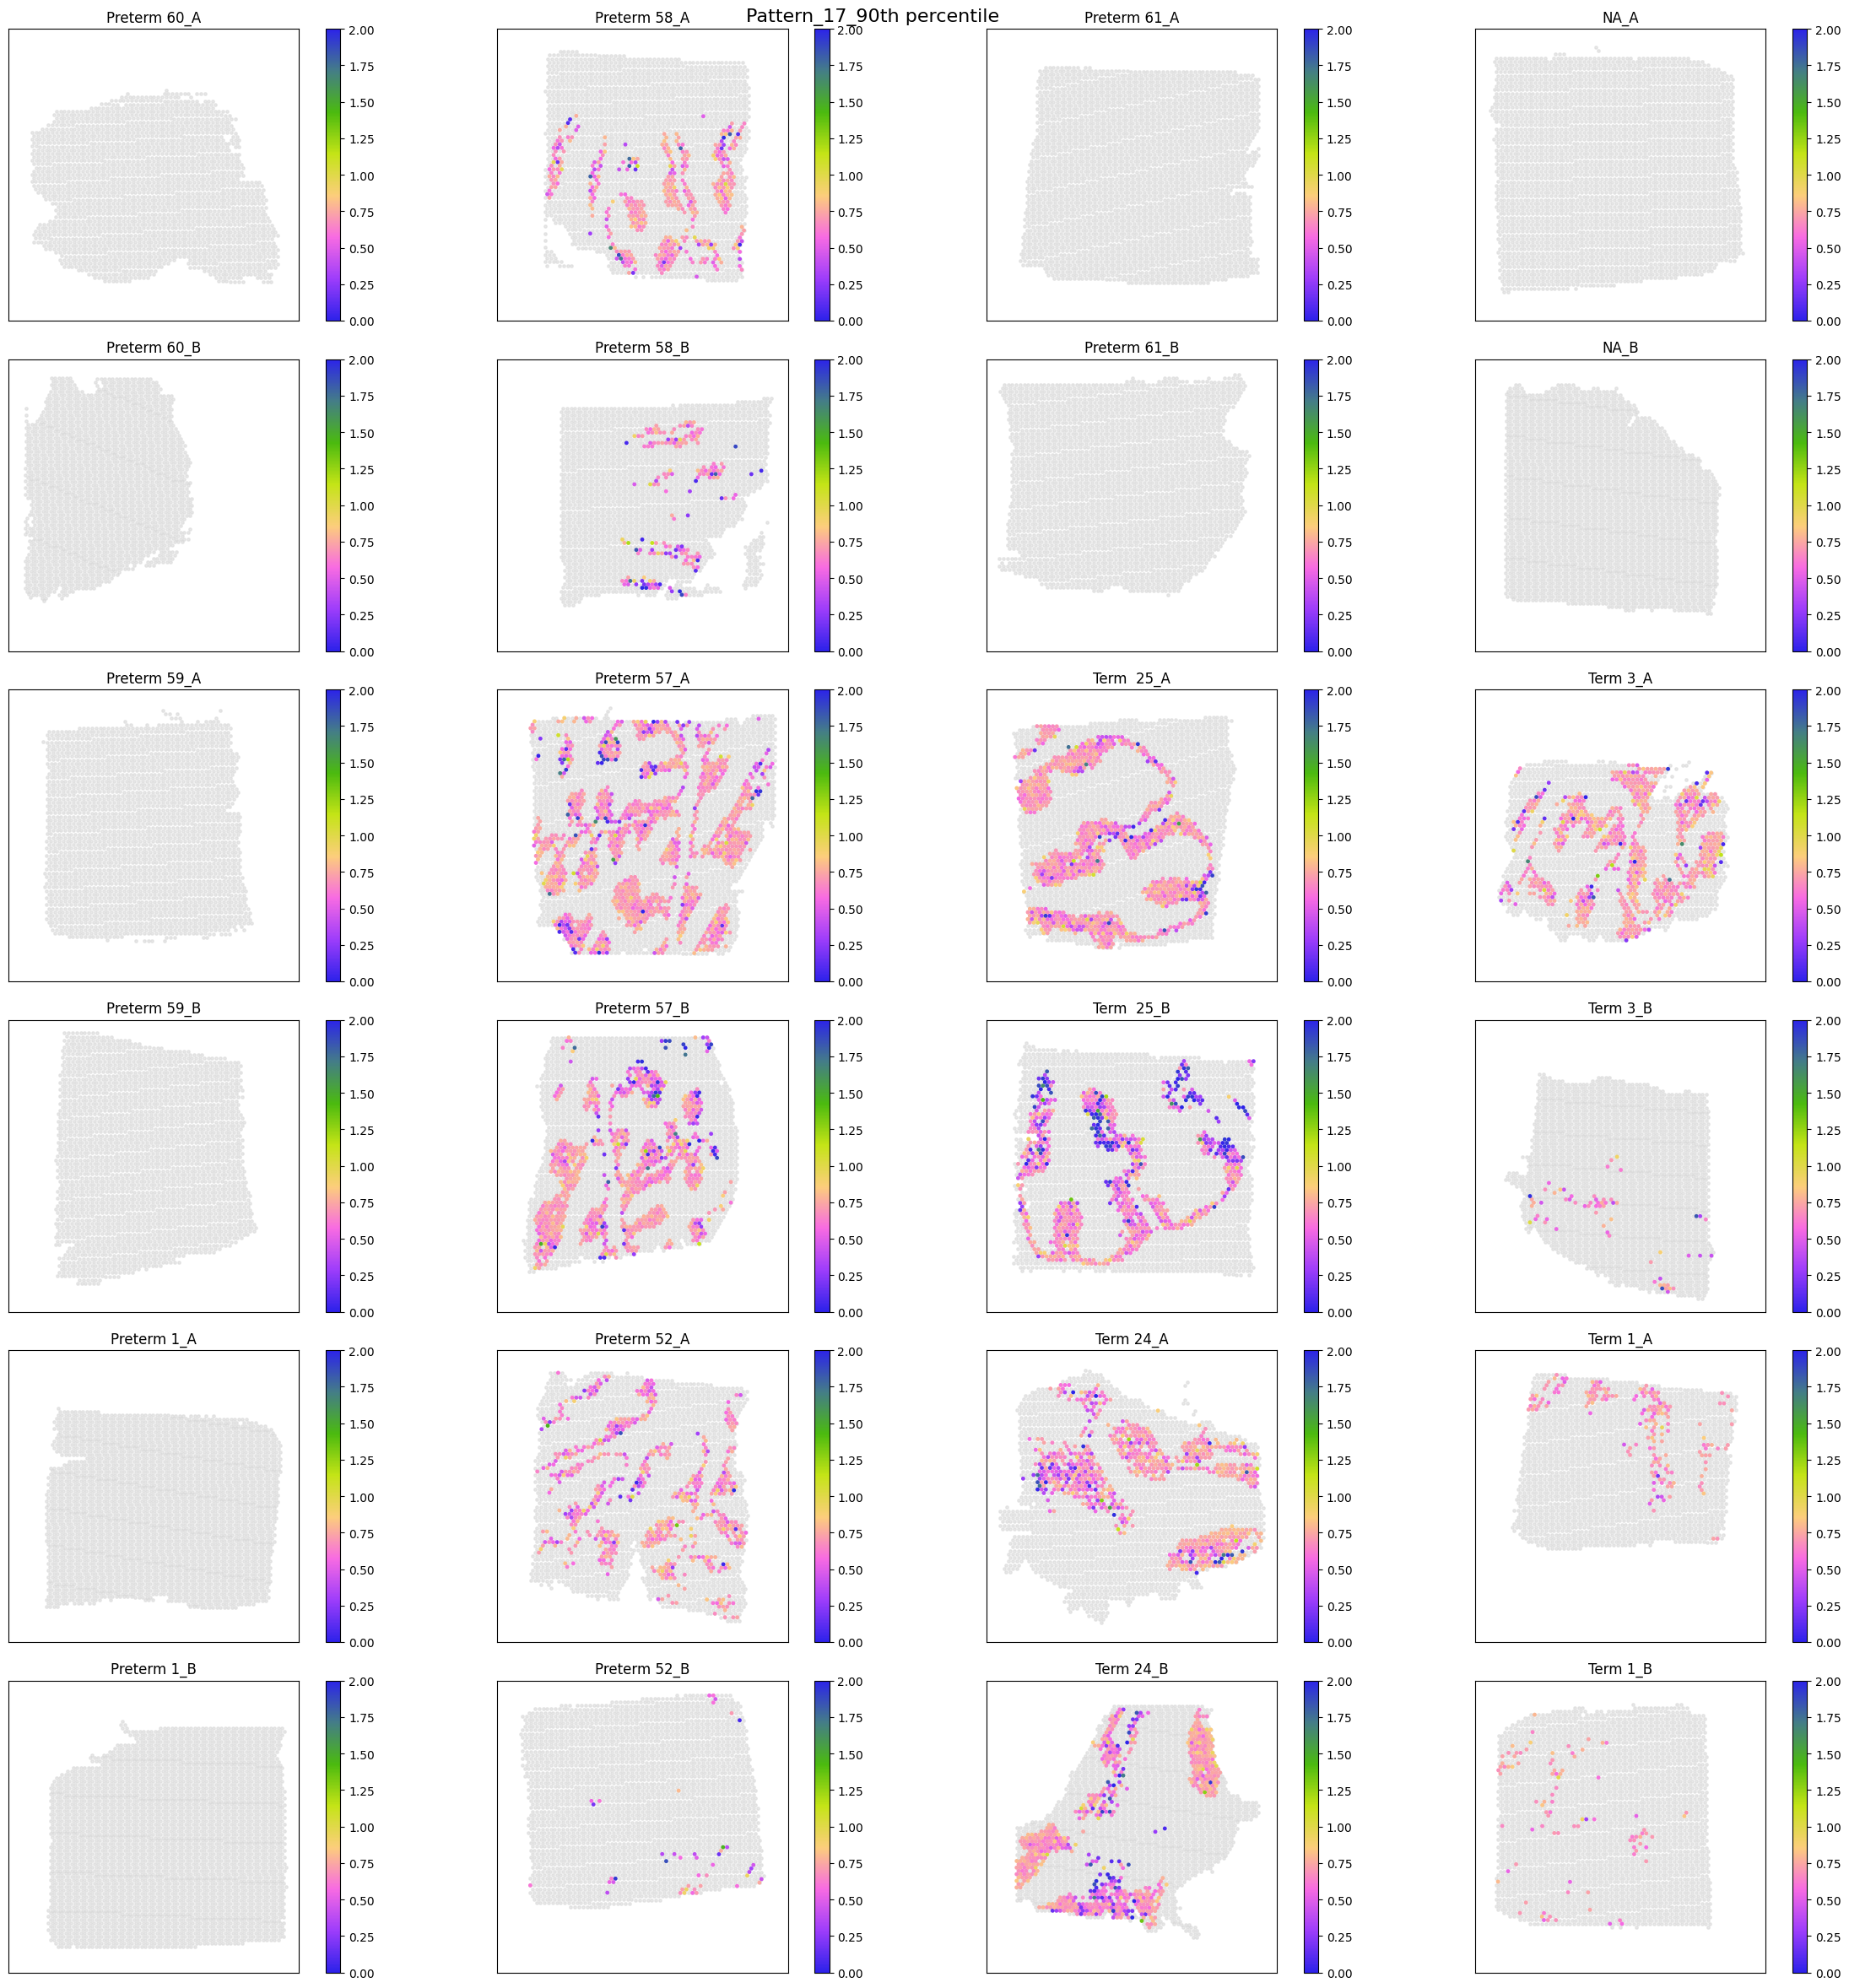

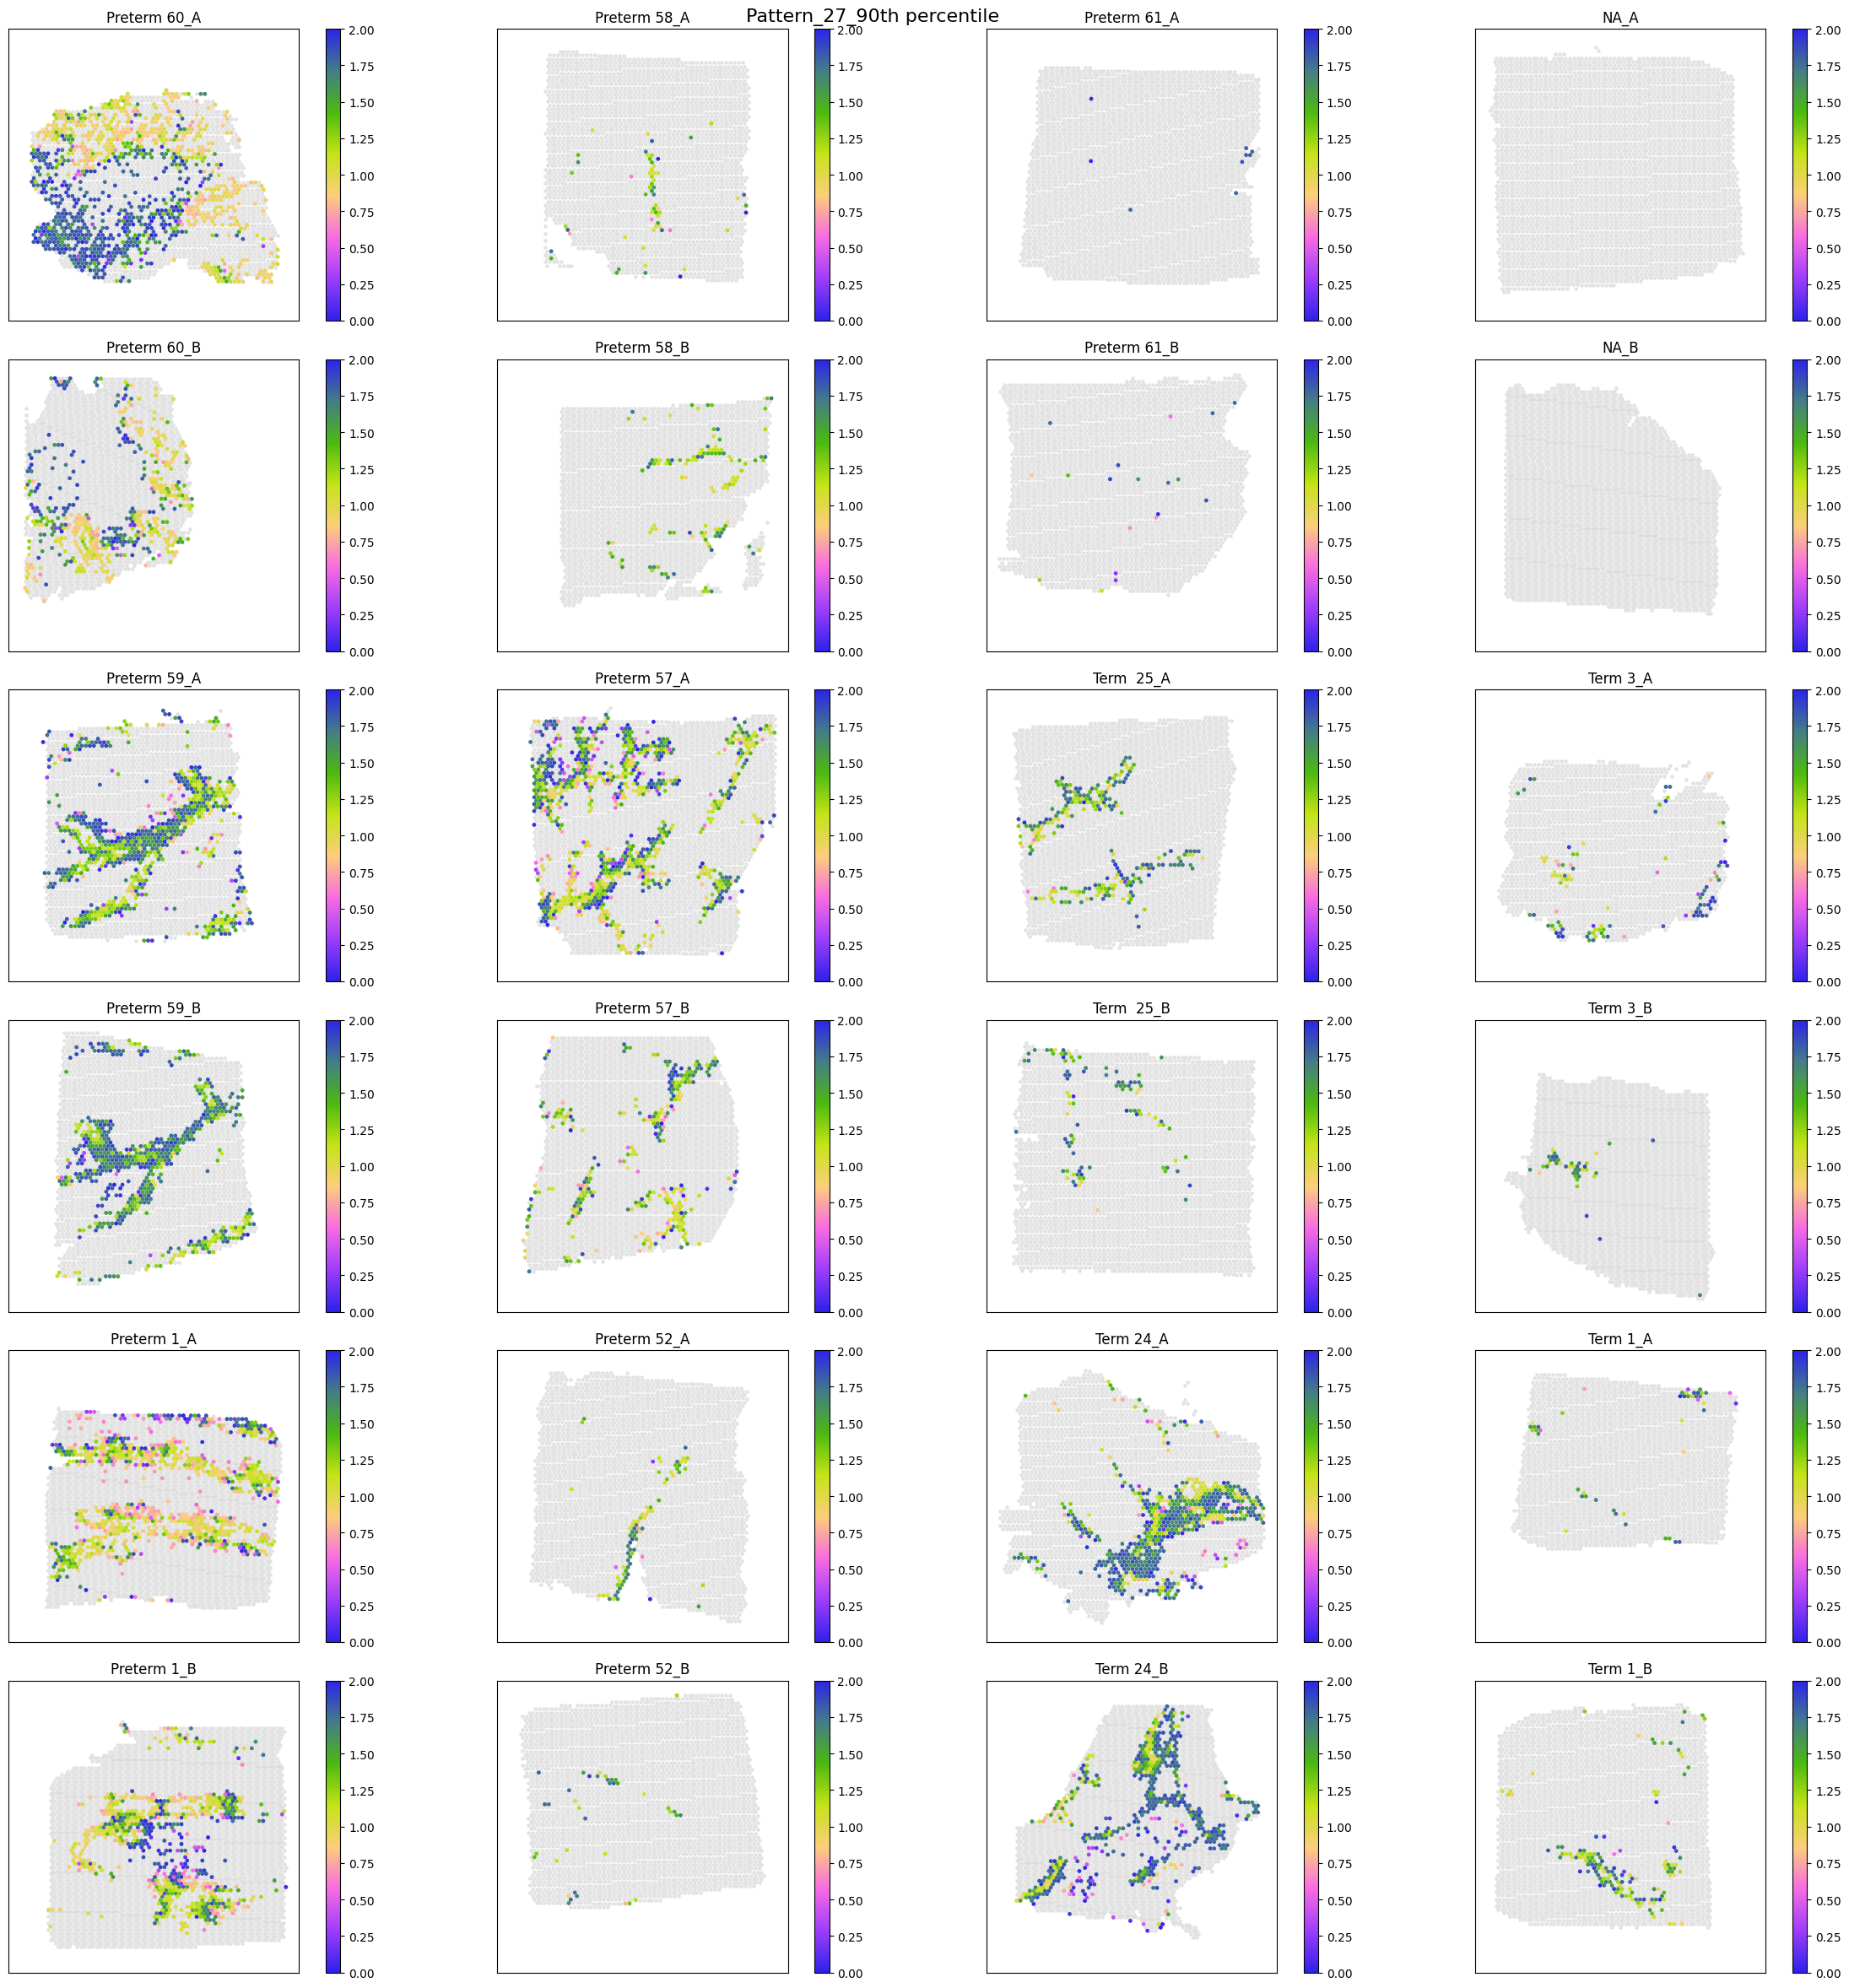

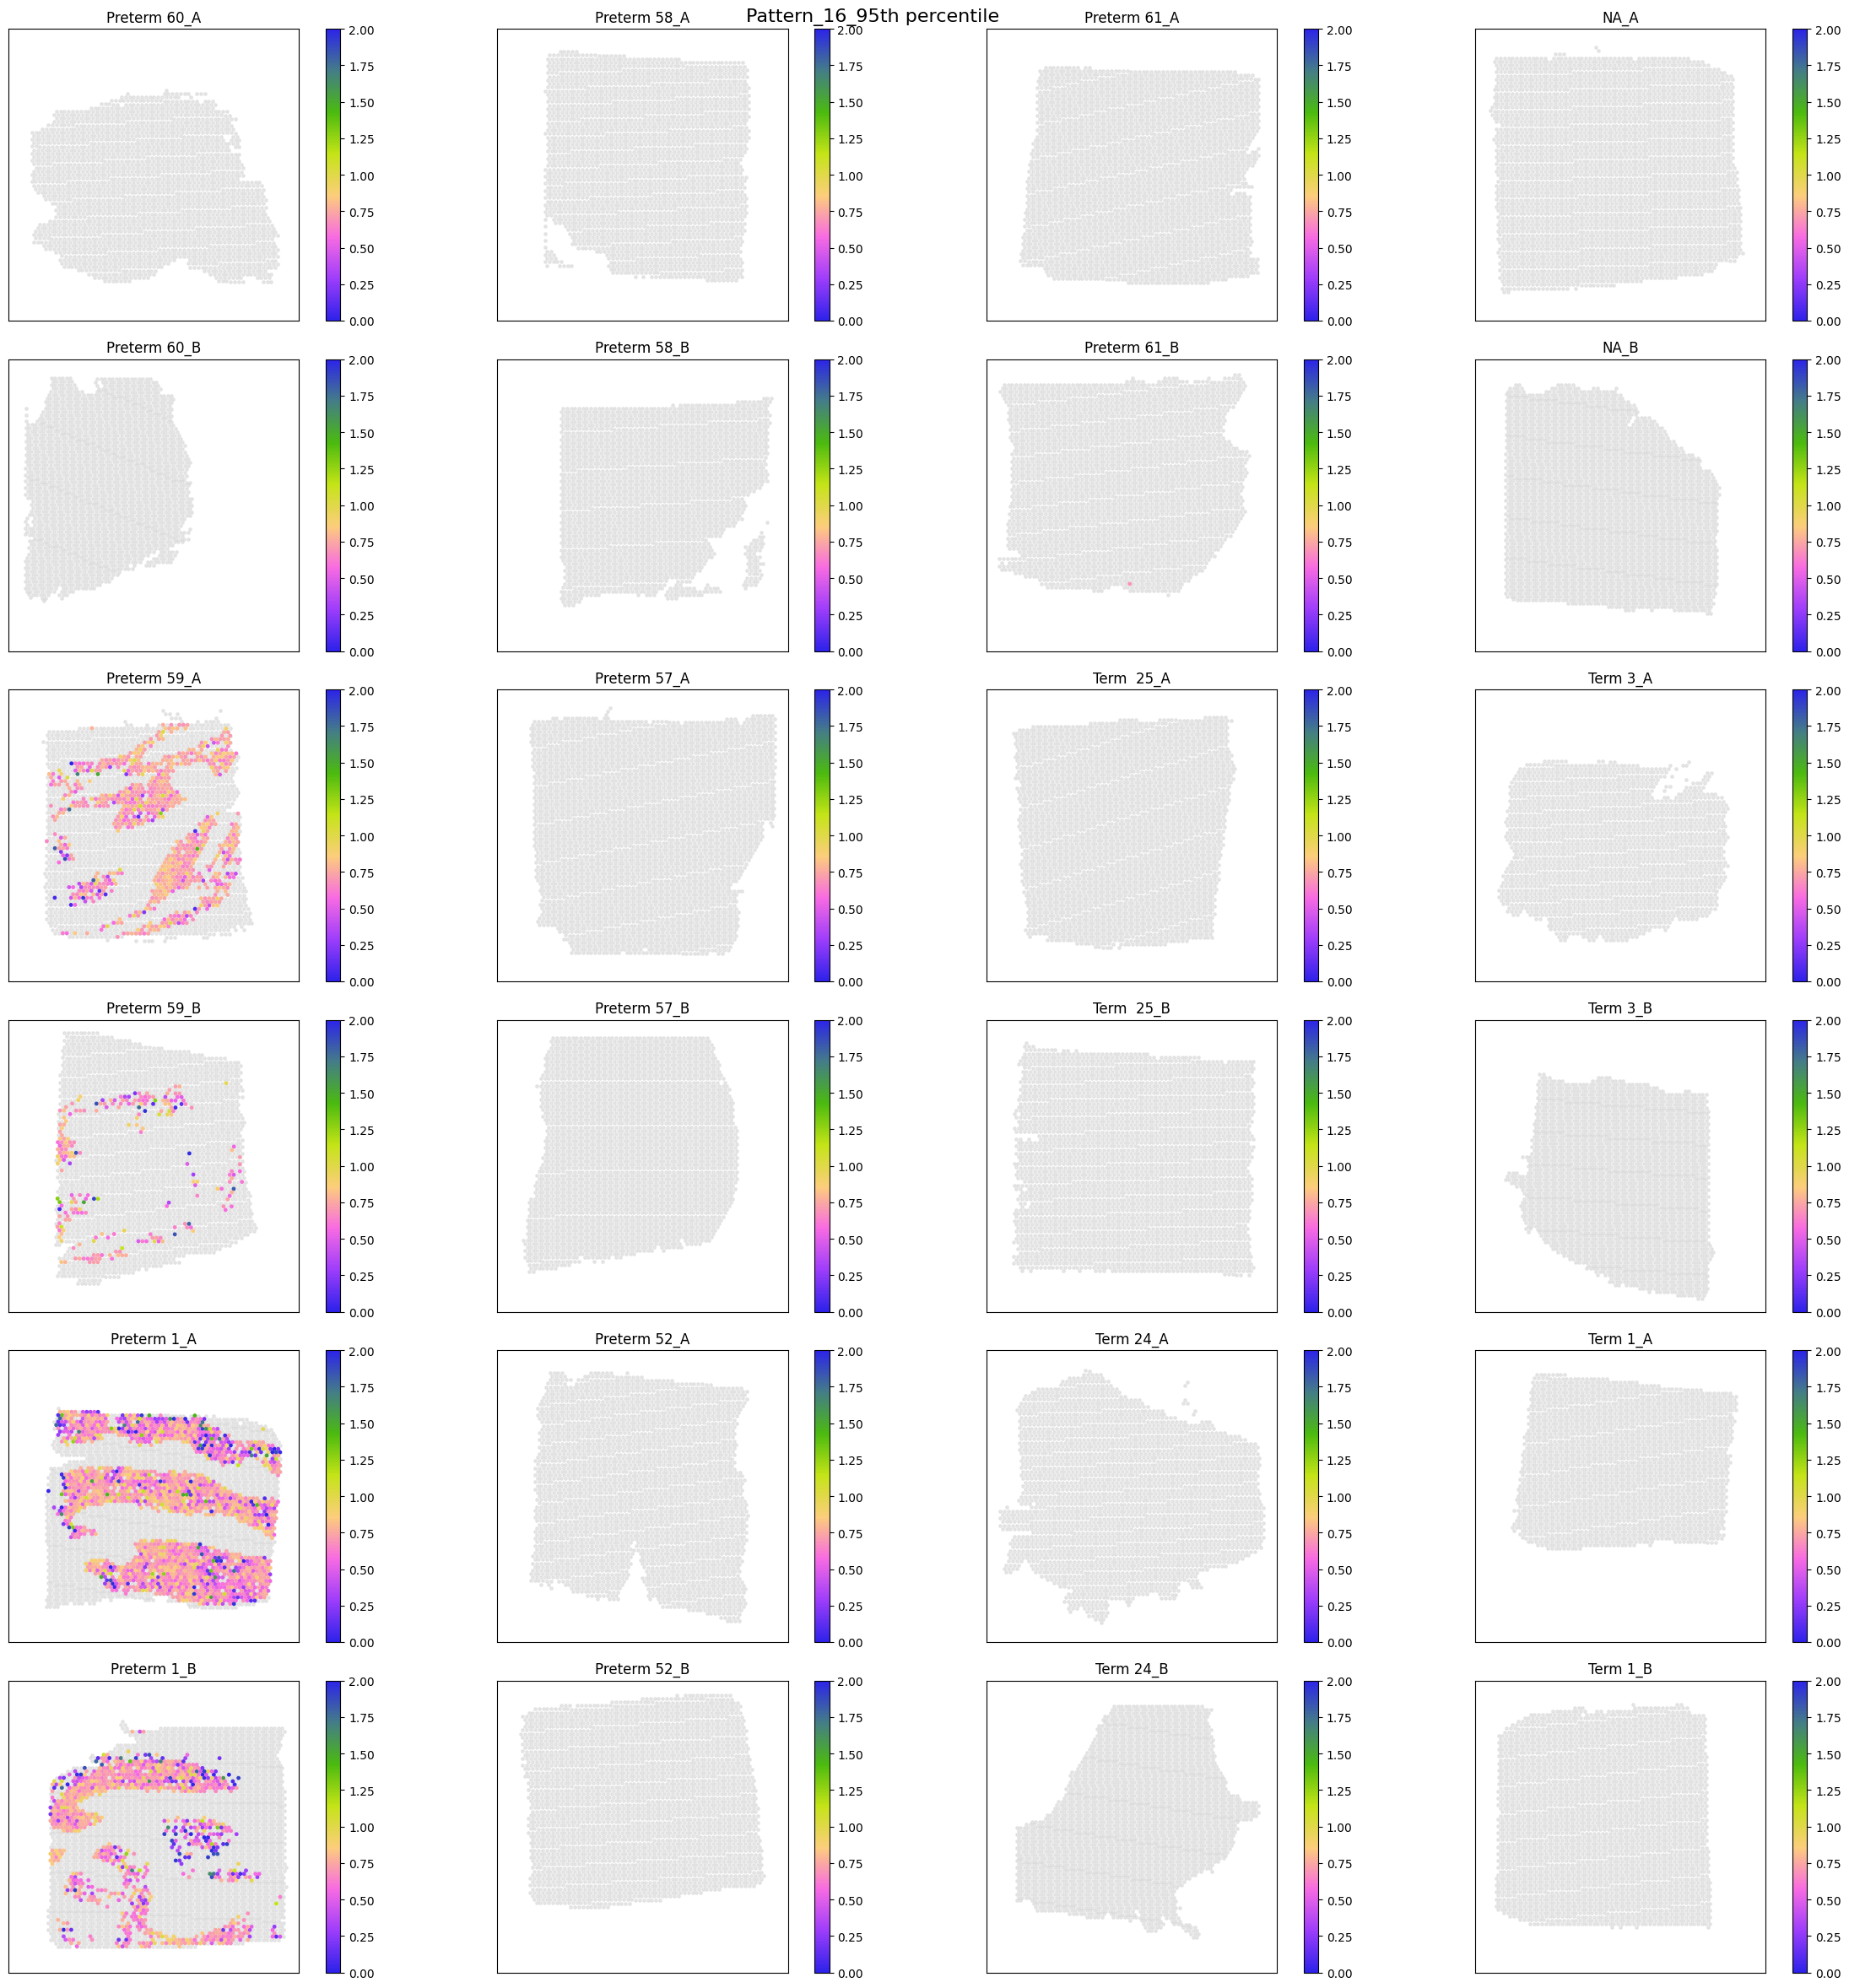

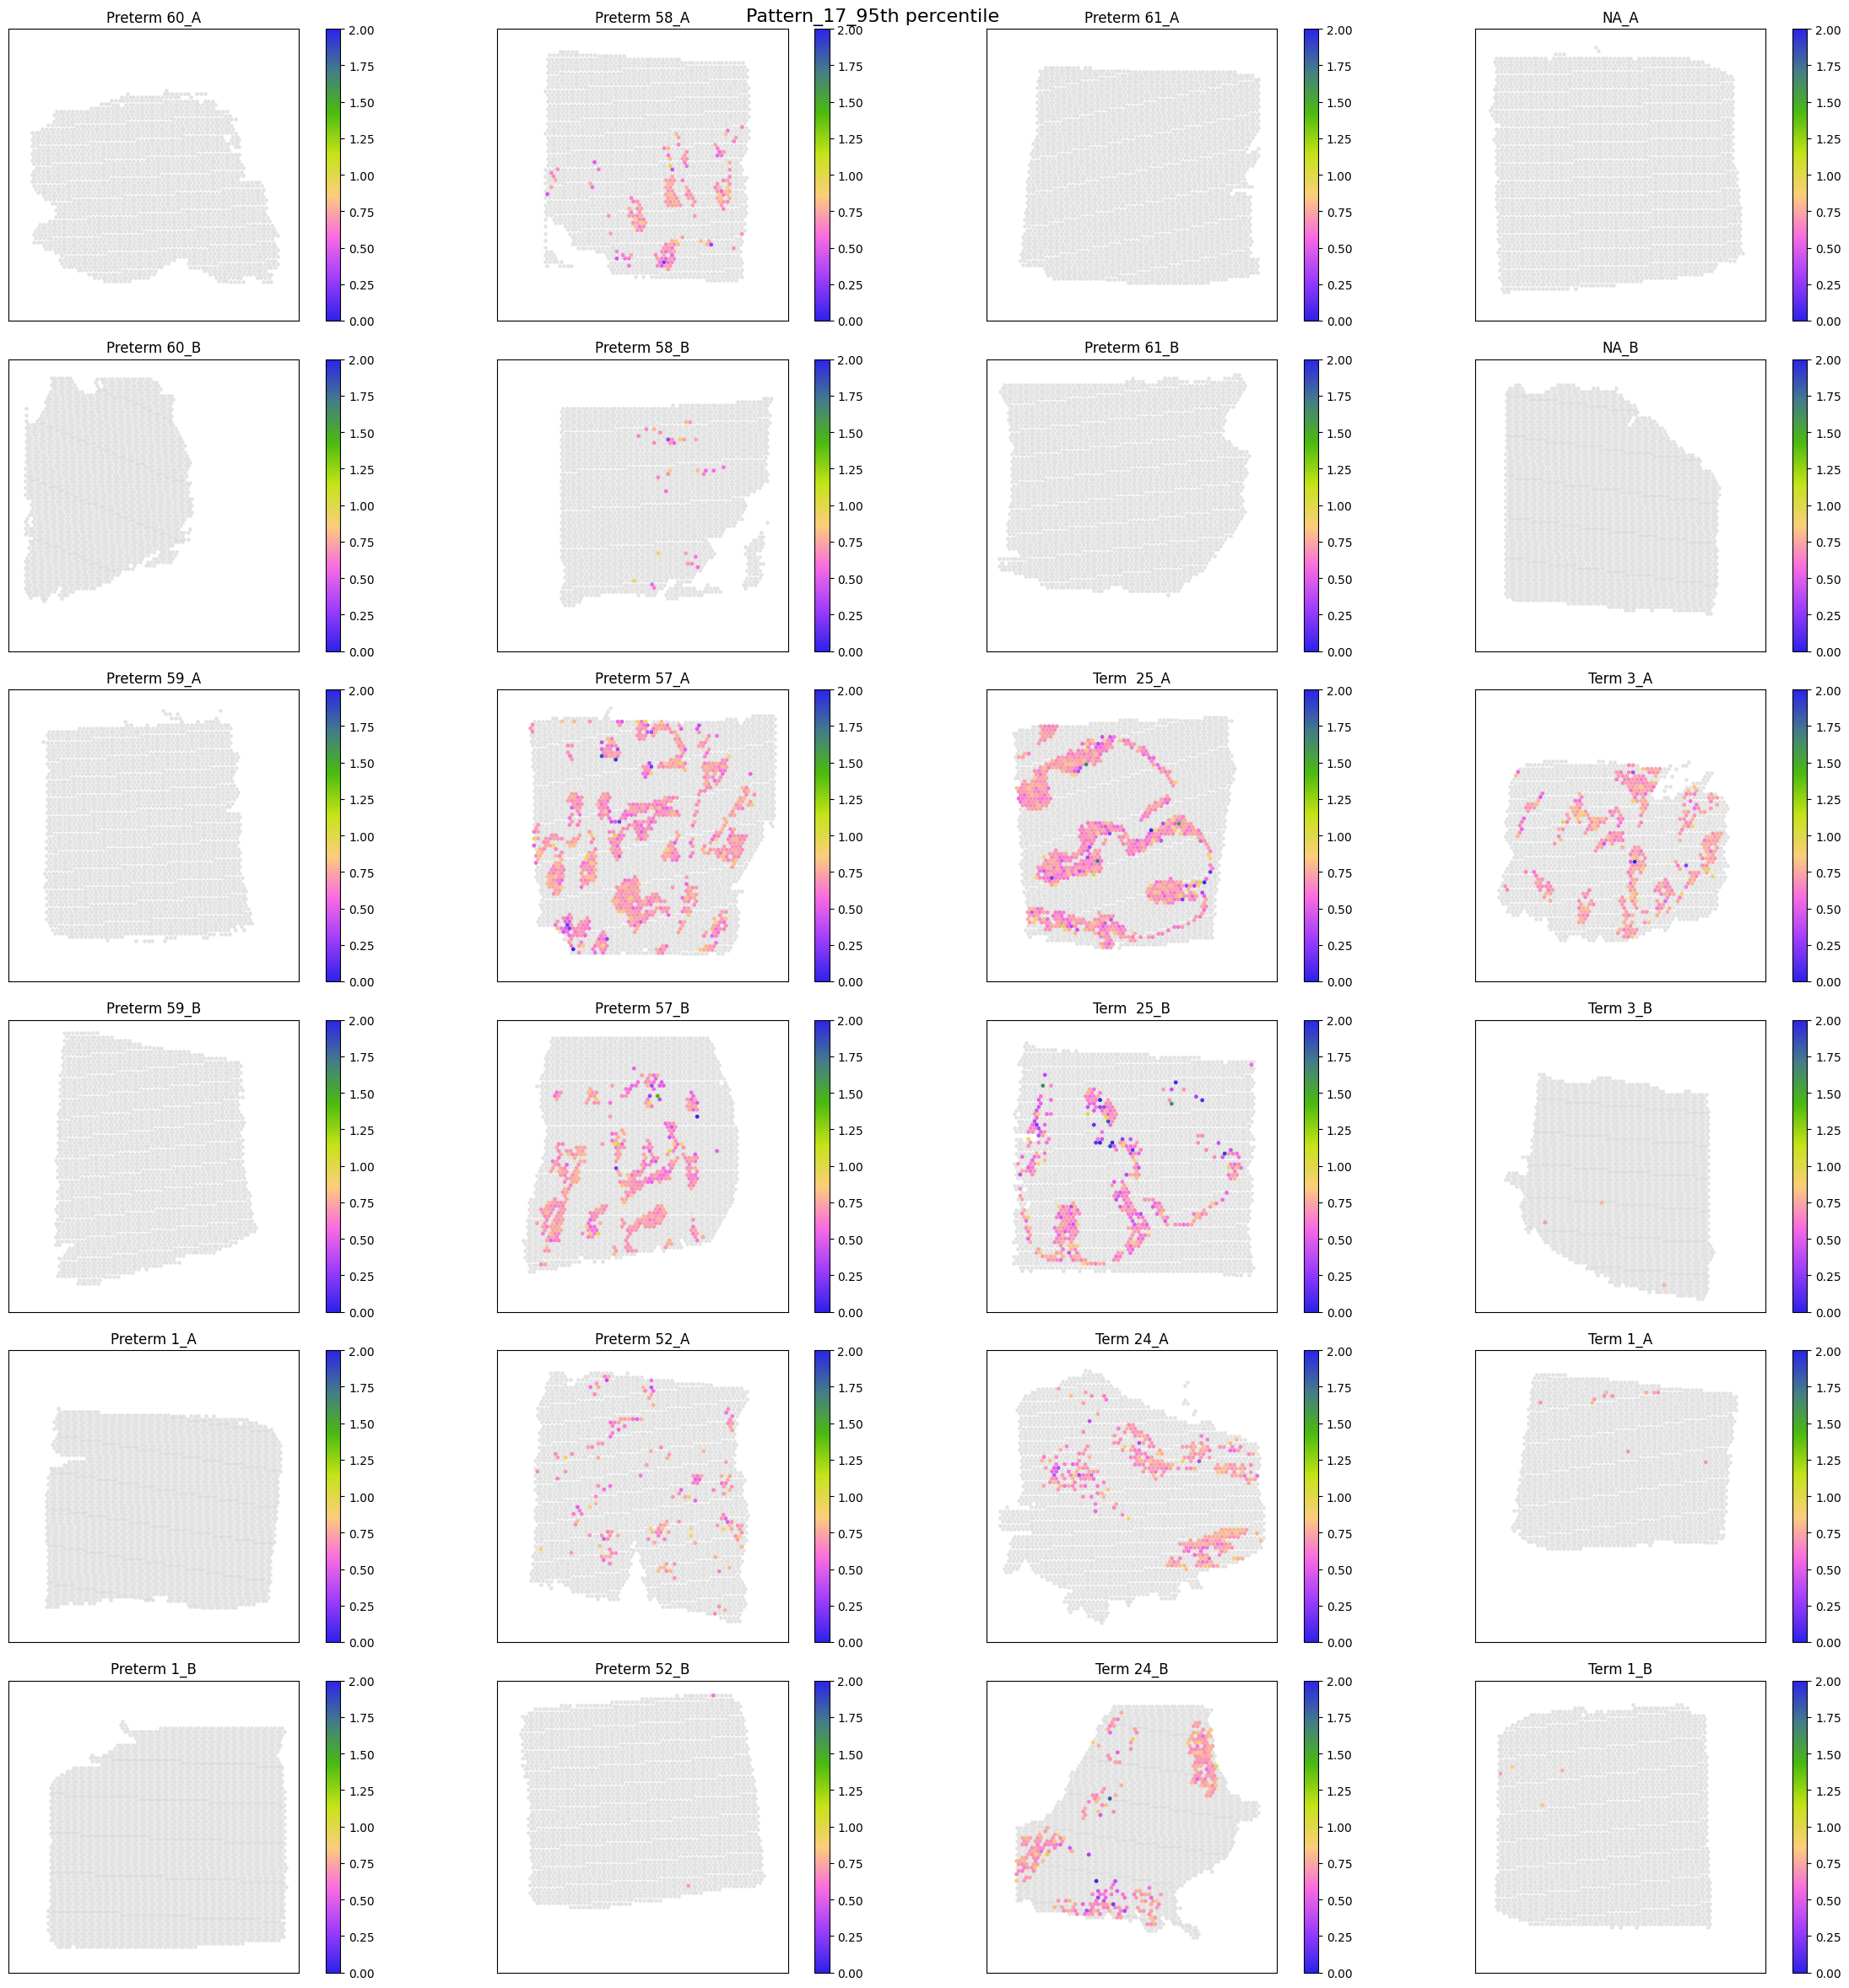

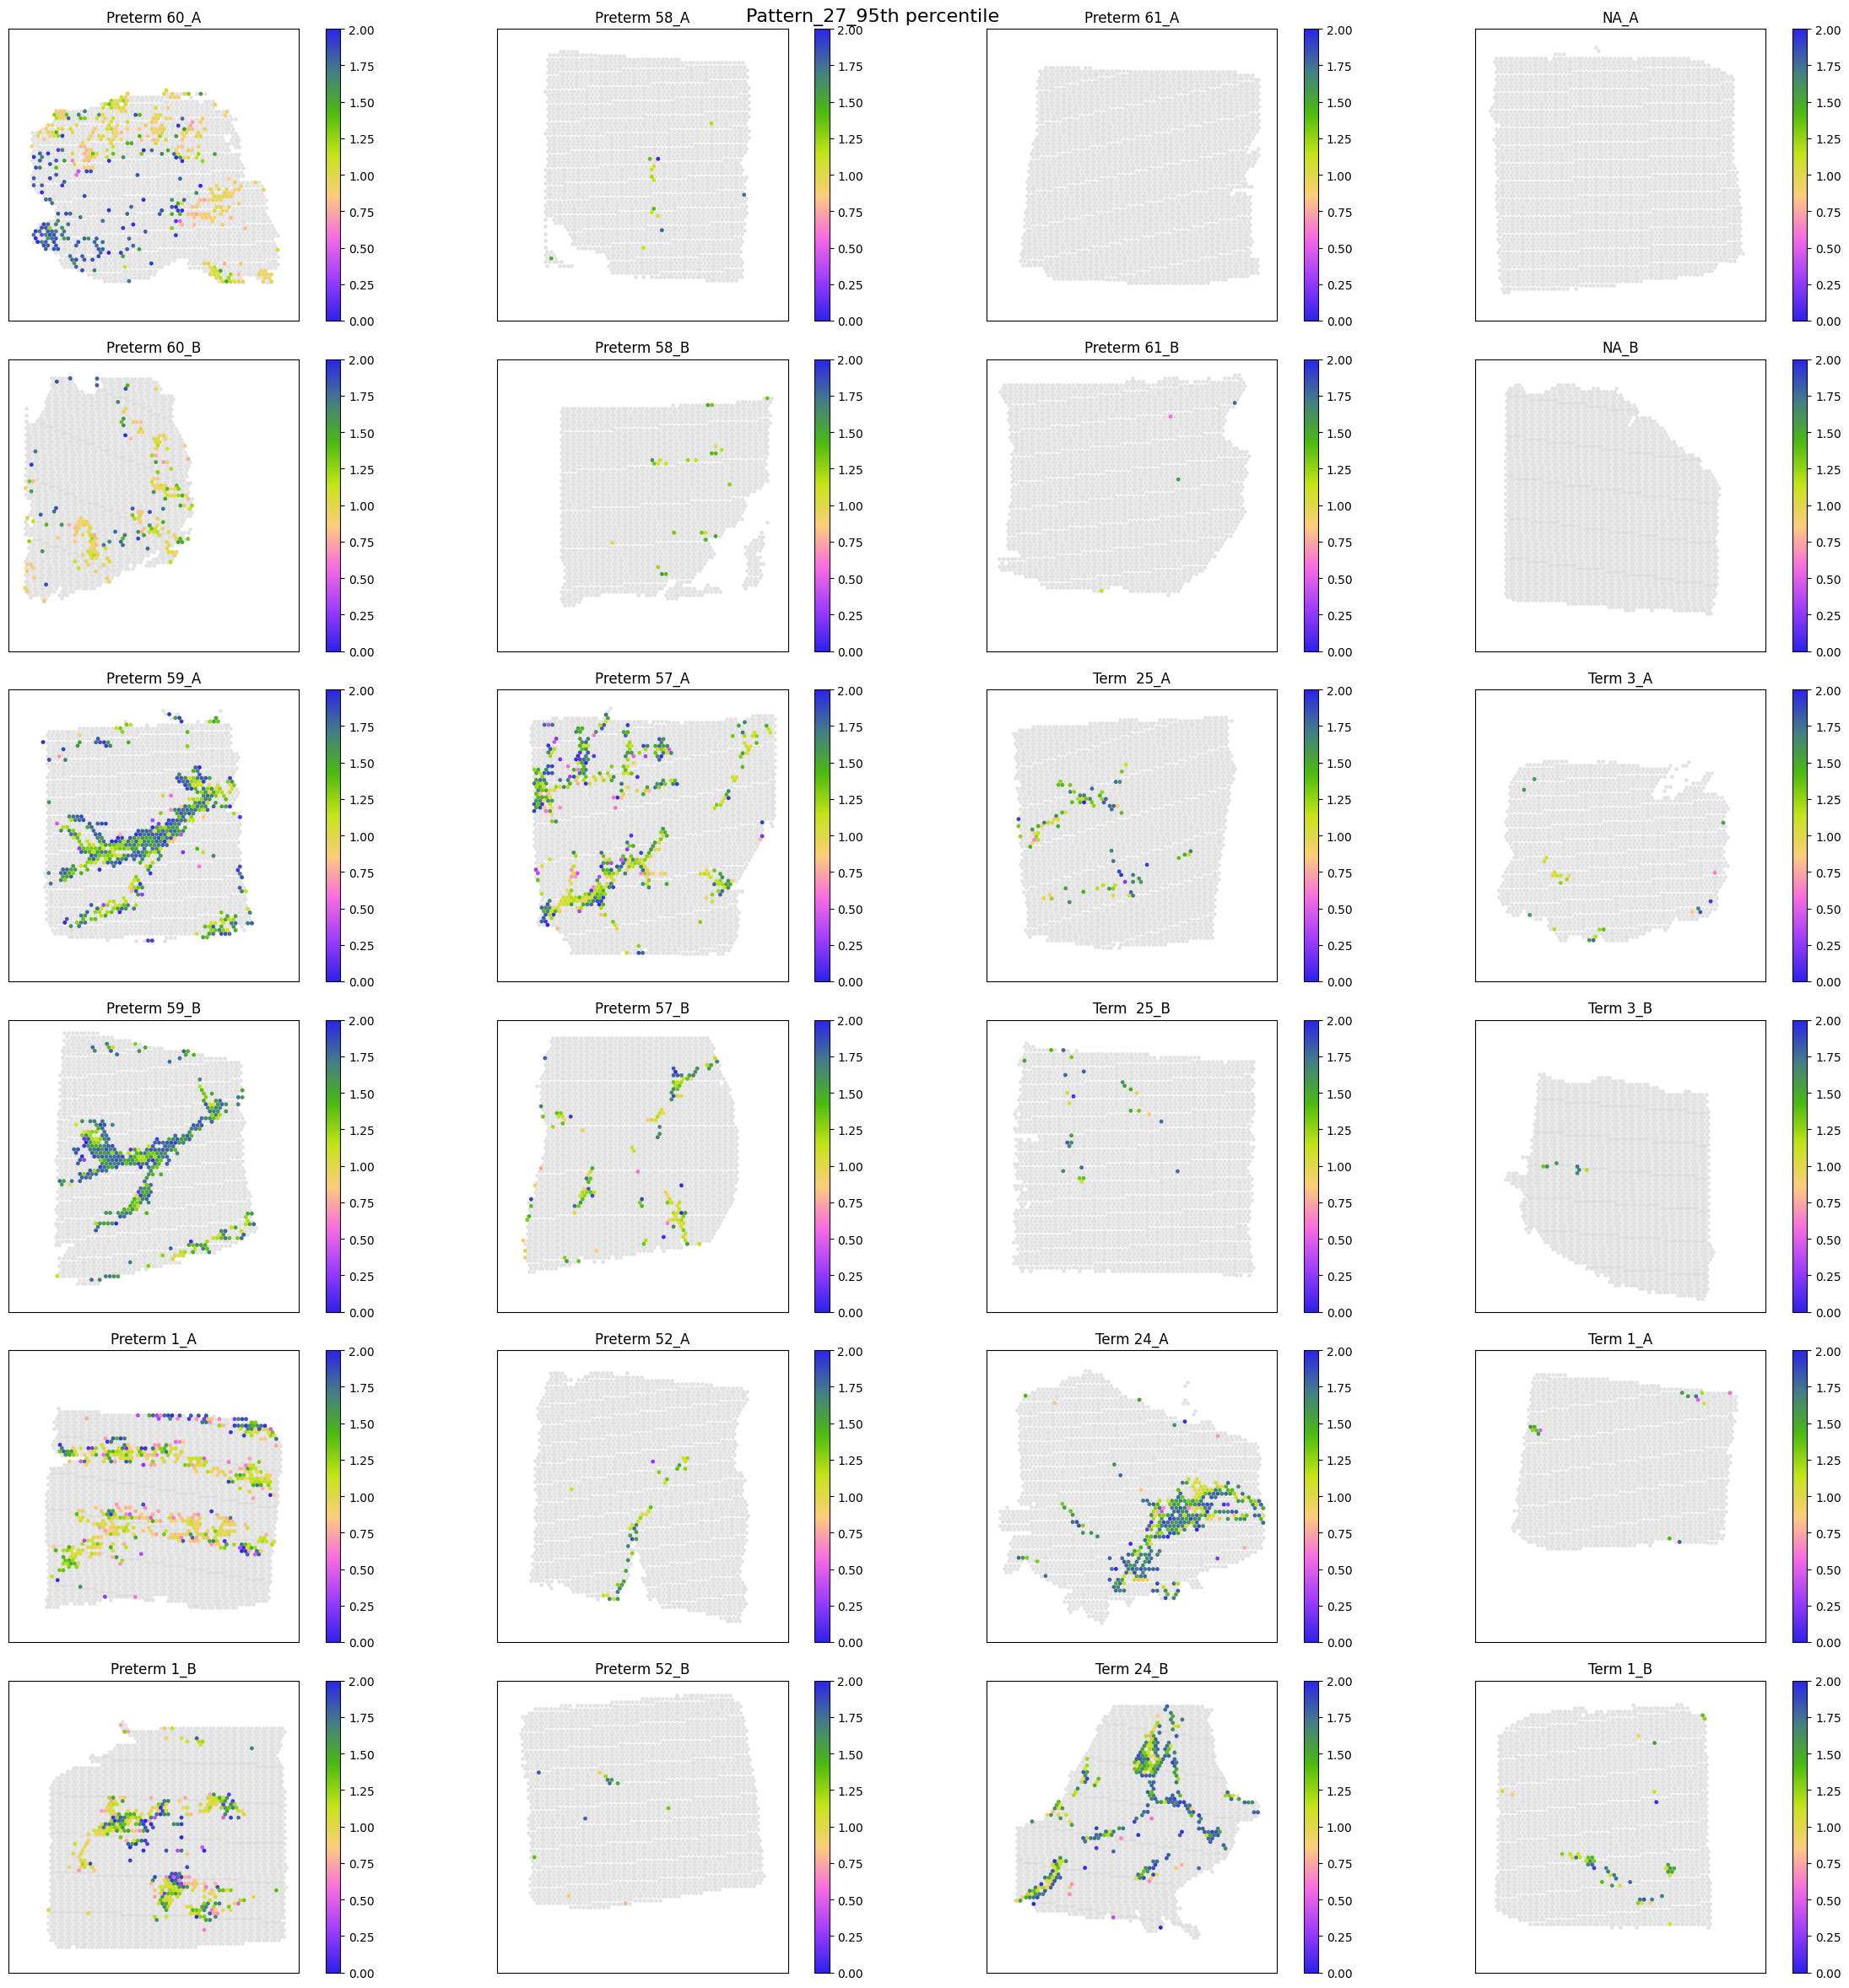

In [43]:
# Plot tricycle theta values spatially for binary patterns

samples = clinical_meta.sort_values(by=['Gestational Age (Weeks)','patient_replicate']).loc[:,'patient_replicate'].unique()

for pat in binary.columns:
    pattern_full = binary.loc[:,pat] # per pattern
    #cutoff = np.percentile(pattern_full, 90)
    fig,axes = plt.subplots(6,4,figsize=(24,24),sharex=True,sharey=True)
    i = 0
    for c in range(axes.shape[1]):
        for r in range(axes.shape[0]):
            sample = samples[i]
            patterns_sub = binary.loc[data.obs['patient_replicate'] == sample,:]
            axes[r,c].set(aspect='equal')
            #scat_background = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=1, alpha=0.1,c='gray')
            scat = axes[r,c].scatter(coords.loc[patterns_sub.index,'imagerow'],coords.loc[patterns_sub.index,'imagecol'], edgecolor=None, s=6,c='lightgray', alpha = 0.5)
            scat = axes[r,c].scatter(coords.loc[patterns_sub.index,'imagerow'],coords.loc[patterns_sub.index,'imagecol'], edgecolor=None, s=6,c=patterns_sub.loc[:,pat] * tricycle_pos.loc[patterns_sub.index,'tricyclePosition_theta'], alpha = patterns_sub.loc[:,pat],cmap=rug_cmap,vmin=0, vmax=2)
            axes[r,c].set_aspect('equal')
            #print(sample.unique())

            axes[r,c].set_yticklabels([])
            axes[r,c].set_xticklabels([])
            axes[r,c].set_xticks([])
            axes[r,c].set_yticks([])

            axes[r,c].set_title(f"{sample}")
            fig.colorbar(scat, ax=axes[r,c])

            #plt.color_bar()
            #fig.colorbar(ax=ax)
            #plt.color_bar()
            i+=1
    plt.suptitle(f"{pat}th percentile", fontsize=16)
    plt.tight_layout()
    #plt.savefig(f"/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/tricycle_pattern_plots/binary_patterns/{pat}_tricycleValues.pdf", bbox_inches='tight')